# Introduction to Convolutional Neural Network and Computer vision


### Get the data

The images we're working with are from the food101 dataset(101 different classes of food): https://www.kaggle.com/datasets/dansbecker/food-101

However we've modified it to only use two classes (pizza and steak). We're starting with a smaller problem, and then we scale up to the full 101 dataset

In [ ]:
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# unzip the downloaded file
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

--2026-04-09 09:11:15--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.188.207, 74.125.20.207, 108.177.98.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.188.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   119MB/s    in 0.9s    

2026-04-09 09:11:16 (119 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



## Insoect the data

A very crucial step at the beginning of any machine learning project is becoming one with the data.

This could mean visualizing your data

In [ ]:
# List the files in pizza steak
!ls pizza_steak

test  train


In [ ]:
!ls pizza_steak/train

pizza  steak


In [ ]:
!ls pizza_steak/train/steak

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [ ]:
import os

# Walk through pizza-steak directory and list number of files
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

There are 2 directories and 0 images in pizza_steak
There are 2 directories and 0 images in pizza_steak/test
There are 0 directories and 250 images in pizza_steak/test/steak
There are 0 directories and 250 images in pizza_steak/test/pizza
There are 2 directories and 0 images in pizza_steak/train
There are 0 directories and 750 images in pizza_steak/train/steak
There are 0 directories and 750 images in pizza_steak/train/pizza


In [ ]:
# Another way to find the number of images are in a file
num_steak_image_train = len(os.listdir("pizza_steak/train/steak"))

num_steak_image_train

750

To visualize our images, first let's get the class names programmatically

In [ ]:
# Get the classnames
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train/")
# Create a list of class names from in the training data
class_names = np.array(sorted([item.name for item in data_dir.glob("*")]))
class_names

array(['pizza', 'steak'], dtype='<U5')

In [ ]:
# Let's visualize our image
import matplotlib.pyplot as plt
import matplotlib.image as mp
import random

def view_random_image(target_dir, target_class):
  # setup the target directory (we'll view images from here)
  target_folder = target_dir+target_class
  # Get a random image path
  random_image_path = random.sample(os.listdir(target_folder), 1)
  # Read in the image and plot it using matplotlib
  img = mp.imread(target_folder + "/" + random_image_path[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}")
  return img

Image shape: (512, 382, 3)


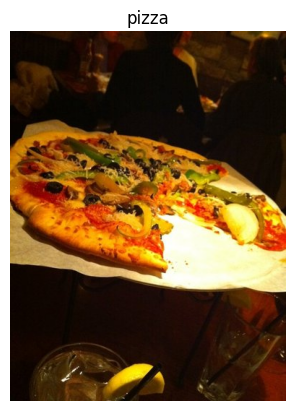

In [ ]:
# View random image from the training dataset
img = view_random_image(target_dir="pizza_steak/train/",
                        target_class="pizza")

In [ ]:
img.shape # width, height, colour channels

(512, 382, 3)

Get all the pixel values between 0 and 1(Normalize). This can be done by dividing the image tensors by 255. We would be carrying out the following steps:
* Load Images
* Preprocess our images
* Build a CNN to find patterns in our images
* Compile our CNN
* fit the CNN to our training data


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the seed
tf.random.set_seed(42)

# preprocess the data
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup paths to our data directories
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"

# Import data from directories and turn into batches(outputss both data and labels)
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                            batch_size=32,
                                            target_size=(224,224),
                                            class_mode="binary",
                                            seed=42)
valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode="binary",
                                               seed=42)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [ ]:
# Build a CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation="relu",
                           input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding="valid"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile our CNN
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# fit the model
history_1 = model.fit(train_data,
                      epochs=20,
                      steps_per_epoch=len(train_data),
                      validation_data=valid_data,
                      validation_steps=len(valid_data))

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 251ms/step - accuracy: 0.6693 - loss: 0.5917 - val_accuracy: 0.8180 - val_loss: 0.4164
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.7880 - loss: 0.4593 - val_accuracy: 0.8400 - val_loss: 0.3766
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.8220 - loss: 0.4229 - val_accuracy: 0.8560 - val_loss: 0.3581
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.8420 - loss: 0.3801 - val_accuracy: 0.8440 - val_loss: 0.3508
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.8593 - loss: 0.3363 - val_accuracy: 0.7580 - val_loss: 0.4821
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.8987 - loss: 0.2664 - val_accuracy: 0.8360 - val_loss: 0.3858
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.9227 - loss: 0.2165 - val_accuracy: 0.8520 - val_loss: 0.3747
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.9607 - loss: 0.1254 - val_accuracy: 

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

### Compare an MLP model with the convolutional layer we just built

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Create a model to replicate the TensorFlow Playground Model
Mlp_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
Mlp_model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                  optimizer=tf.keras.optimizers.Adam(0.001),
                  metrics=["accuracy"])

# Fit the model
Mlp_model.fit(train_data,
              epochs=20,
              steps_per_epoch=len(train_data),
              validation_data=valid_data,
              validation_steps=len(valid_data))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.6293 - loss: 5.1914 - val_accuracy: 0.7280 - val_loss: 1.5194
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.6820 - loss: 2.3797 - val_accuracy: 0.7360 - val_loss: 1.0118
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.7207 - loss: 1.0116 - val_accuracy: 0.6460 - val_loss: 1.5180
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.7093 - loss: 1.2637 - val_accuracy: 0.7580 - val_loss: 0.7986
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.7860 - loss: 0.6653 - val_accuracy: 0.7720 - val_loss: 0.5119
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.7993 - loss: 0.4826 - val_accuracy: 0.7580 - val_loss: 0.6558
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.8487 - loss: 0.3740 - val_accuracy: 0.6160 - val_loss: 1.1739
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.8053 - loss: 0.4947 - val_accuracy: 0.

In [ ]:
Mlp_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,189,305 (172.38 MB)

 Trainable params: 15,063,101 (57.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,126,204 (114.92 MB)

## Binary Classification: Let's break it down

1. Become one with the data(Visualize, Visualize, Visualize)
2. Preprocess the data(prepared it for our model, the main step here was scaling/normalizing)
3. Created a model (start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve the model(try to beat our baseline)
7. Repeat until satisfied (experiment, experiment, experiment)

###1. Become one with the data

Image shape: (512, 512, 3)
Image shape: (512, 512, 3)


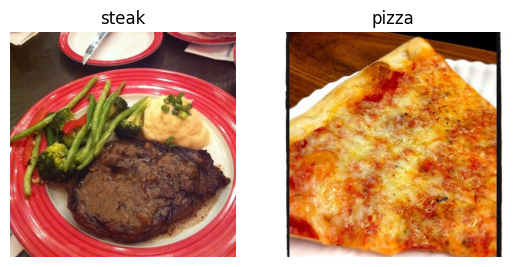

In [ ]:
# Visualize data
plt.figure()
plt.subplot(1, 2, 1)
steak_img = view_random_image("pizza_steak/train/", "steak")
plt.subplot(1, 2, 2)
pizza_img = view_random_image("pizza_steak/train/", "pizza")

###2. Preprocess the data(Prepare the data for our model)

In [ ]:
# Define directory dataset paths
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"

In [ ]:
# Turn our data into batches
# Create train and test data generators and rescale the data
# ImageDataGenerator is used to create batches of augunented data
from tensorflow.keras.preprocessing.image  import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

In [ ]:
# Load in our data from directory and turn them into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               batch_size=32,
                                               shuffle=False)
test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(224,224),
                                             class_mode="binary",
                                             batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [ ]:
images, labels = next(train_data)

###3. Create a model

In [ ]:
# Import all the tools we need to build our model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Activation, Flatten, BatchNormalization
from tensorflow.keras import Sequential

In [ ]:
# Create the model
model_1 = Sequential([
    Conv2D(filters=10,
           kernel_size=3,
           strides=1,
           padding="valid",
           activation="relu",
           input_shape=(224, 224, 3)),
    Conv2D(10, 3, activation="relu"),
    Conv2D(10, 3, activation="relu"),
    Flatten(),
    Dense(1, activation="sigmoid")
])

In [ ]:
# Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=Adam(),
                metrics=["accuracy"])

### Fit the model on the training data

In [ ]:
# Fit the model
history = model_1.fit(train_data,
                      epochs=5,
                      steps_per_epoch=len(train_data),
                      validation_data=test_data,
                      validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - accuracy: 0.5473 - loss: 1.0428 - val_accuracy: 0.5940 - val_loss: 0.6657
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.6073 - loss: 0.6595 - val_accuracy: 0.6520 - val_loss: 0.6187
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.6840 - loss: 0.6076 - val_accuracy: 0.7200 - val_loss: 0.5257
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.7653 - loss: 0.5318 - val_accuracy: 0.7980 - val_loss: 0.4726
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.8367 - loss: 0.4024 - val_accuracy: 0.5780 - val_loss: 1.0428


In [ ]:
model_1.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.5780 - loss: 1.0428


[1.0428193807601929, 0.578000009059906]

###5. Evaluate our model

<Axes: >

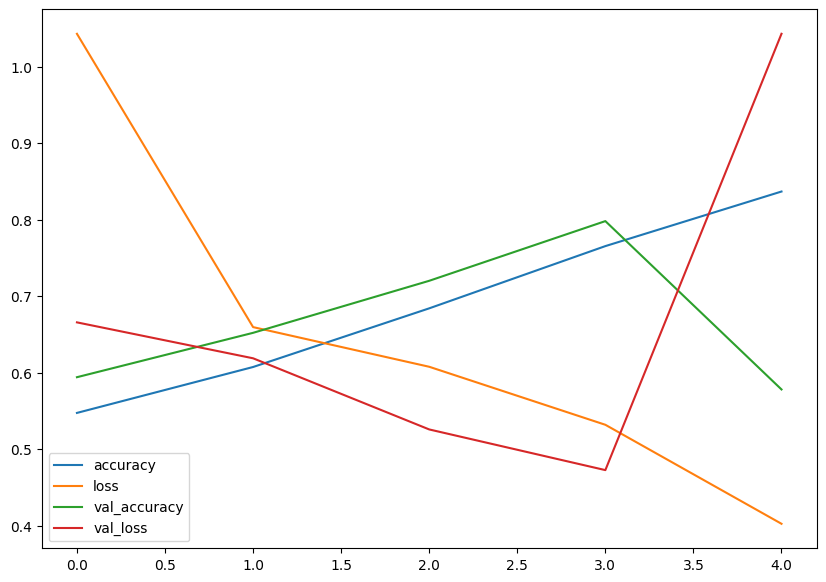

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(10, 7))

In [ ]:
# Plot the validation and training curves seperately
def plot_loss_curves(history):
  """Return seperate loss curves fro training and validation"""
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]

  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]

  epochs = range(len(history.history["loss"]))

  # Plot the loss
  plt.plot(epochs, loss, label="training_loss")
  plt.plot(epochs, val_loss, label="val_loss")
  plt.title("loss")
  plt.xlabel("epochs")
  plt.legend()

  # Plot the accuracy
  plt.figure();
  plt.plot(epochs, accuracy, label="training_accuracy")
  plt.plot(epochs, val_accuracy, label="val_accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend()

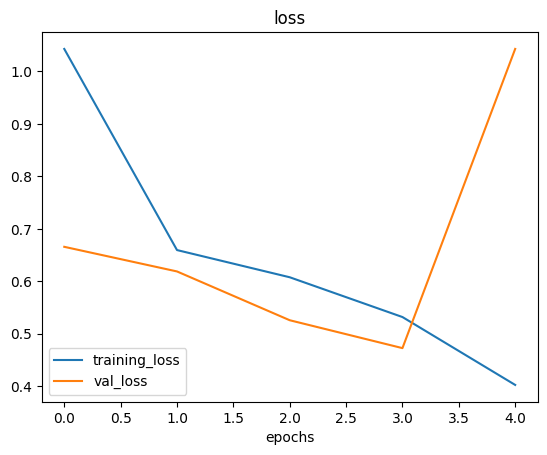

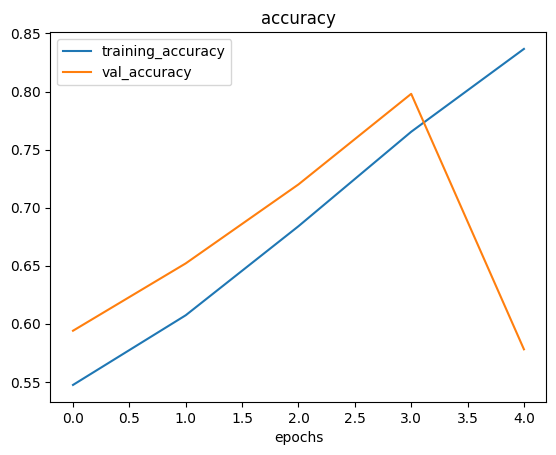

In [ ]:
# Check out the loss and accuracy of our model
plot_loss_curves(history)

### 6. Tweak the model's parameters

In [ ]:
# Create a new model
model_2 = Sequential([
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

In [ ]:
# Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=Adam(),
                metrics=["accuracy"])

In [ ]:
# Fit the model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.5800 - loss: 0.6820 - val_accuracy: 0.5000 - val_loss: 0.7749
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 123ms/step - accuracy: 0.5427 - loss: 0.7161 - val_accuracy: 0.5000 - val_loss: 0.9983
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.5747 - loss: 0.6888 - val_accuracy: 0.6760 - val_loss: 0.6374
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.6320 - loss: 0.6435 - val_accuracy: 0.7340 - val_loss: 0.5468
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.7527 - loss: 0.5304 - val_accuracy: 0.6640 - val_loss: 0.6138


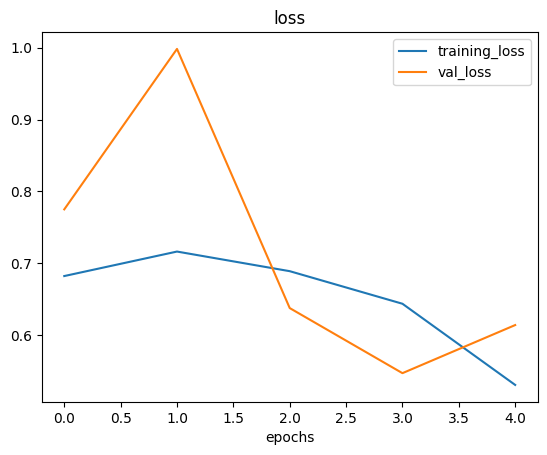

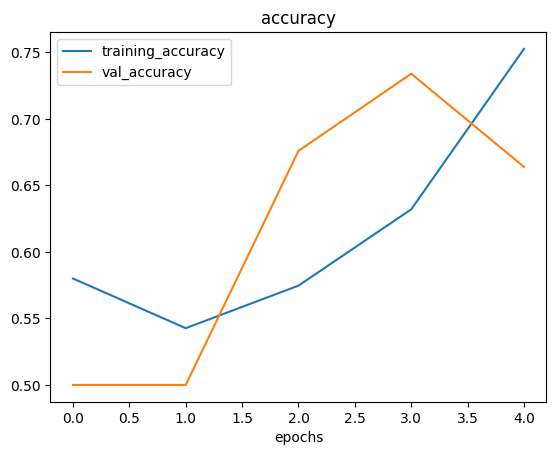

In [ ]:
# Plot the loss and accuracy curve
plot_loss_curves(history_2)

In [ ]:
# Introduce data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=0.1,
                                             shear_range=0.1,
                                             zoom_range=0.1,
                                             width_shift_range=0.2,
                                             height_shift_range=0.1,
                                             horizontal_flip=True)


In [ ]:
# Import data and augment it from training
train_data_augmented = train_datagen_augmented.flow_from_directory(directory=train_dir,
                                                                   target_size=(224, 224),
                                                                   class_mode="binary",
                                                                   shuffle=False)

Found 1500 images belonging to 2 classes.


In [ ]:
# Let's visualize some augmented data
augmented_images, augmented_labels = next(train_data_augmented)

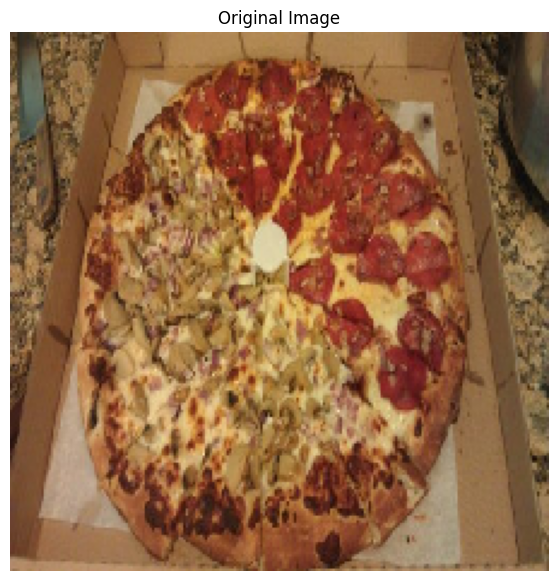

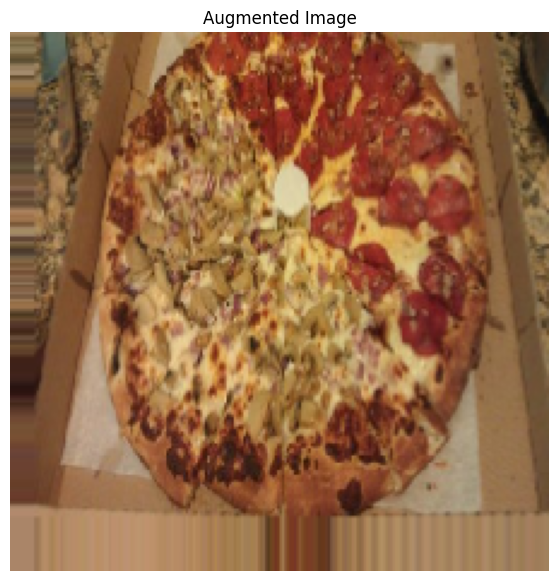

In [ ]:
# Show original image and augmented image
import random
random_number = random.randint(0, 32) # Our batch sizes are 32......
plt.figure(figsize=(10, 7))
plt.imshow(images[random_number])
plt.title("Original Image")
plt.axis("off");

plt.figure(figsize=(10, 7))
plt.title("Augmented Image")
plt.imshow(augmented_images[random_number])
plt.axis("off");

In [ ]:
# Create a model to train on the augmented data
model_3 = Sequential([
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(pool_size=2),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(pool_size=2),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(pool_size=2),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=Adam(),
                metrics=["accuracy"])

# Fit the model
history_3 = model_3.fit(train_data_augmented,
                        epochs=10,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 500ms/step - accuracy: 0.4747 - loss: 0.8117 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 473ms/step - accuracy: 0.4553 - loss: 0.6966 - val_accuracy: 0.6040 - val_loss: 0.6910
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 450ms/step - accuracy: 0.5607 - loss: 0.6912 - val_accuracy: 0.6400 - val_loss: 0.6821
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 40s 439ms/step - accuracy: 0.5833 - loss: 0.6825 - val_accuracy: 0.5240 - val_loss: 0.6635
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 449ms/step - accuracy: 0.5613 - loss: 0.6767 - val_accuracy: 0.6540 - val_loss: 0.6177
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 450ms/step - accuracy: 0.6713 - loss: 0.6293 - val_accuracy: 0.7820 - val_loss: 0.5160
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 461ms/step - accuracy: 0.6773 - loss: 0.6317 - val_accuracy: 0.8100 - val_loss: 0.5709
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 461ms/step - accuracy: 0.7427 - loss: 0.5589 - val_accu

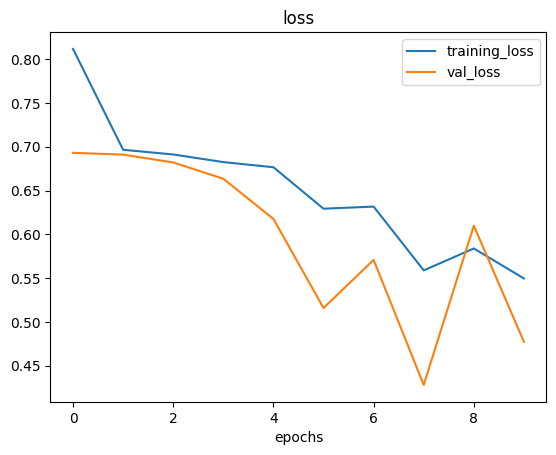

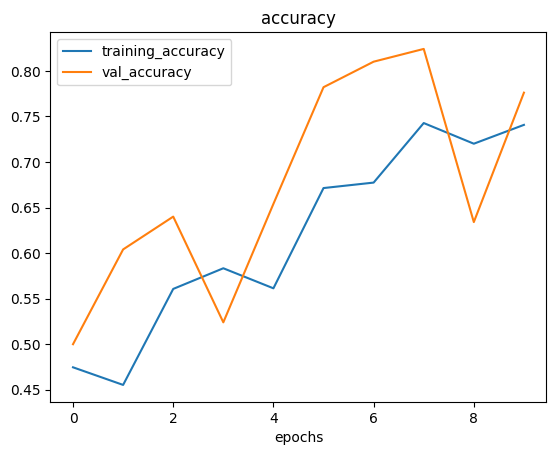

In [ ]:
# Check our model's training curves
plot_loss_curves(history_3)

In [ ]:
# Import data again, augment and shuffle this time
train_data_augmented_shuffle = train_datagen_augmented.flow_from_directory(directory=train_dir,
                                                                           target_size=(224, 224),
                                                                           class_mode="binary",
                                                                           shuffle=True)

Found 1500 images belonging to 2 classes.


In [ ]:
model_4 = Sequential([
    Conv2D(32, 3, activation="relu"),
    BatchNormalization(),
    MaxPool2D(pool_size=2),
    Conv2D(32, 3, activation="relu"),
    MaxPool2D(pool_size=2),
    Conv2D(32, 3, activation="relu"),
    MaxPool2D(pool_size=2),
    BatchNormalization(),
    Conv2D(32, 3, activation="relu"),
    MaxPool2D(pool_size=2),
    Flatten(),
    Dense(1, activation="sigmoid")
])
# Compile the model
model_4.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=Adam(),
                metrics=["accuracy"])

# fit the model
history_4 = model_4.fit(train_data_augmented_shuffle,
                        epochs=15,
                        steps_per_epoch=len(train_data_augmented_shuffle),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 551ms/step - accuracy: 0.7113 - loss: 0.6343 - val_accuracy: 0.5440 - val_loss: 0.7005
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 442ms/step - accuracy: 0.7853 - loss: 0.4771 - val_accuracy: 0.5020 - val_loss: 0.8268
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 513ms/step - accuracy: 0.8100 - loss: 0.4401 - val_accuracy: 0.5260 - val_loss: 0.8021
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 443ms/step - accuracy: 0.8240 - loss: 0.4028 - val_accuracy: 0.6180 - val_loss: 0.6232
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 459ms/step - accuracy: 0.8327 - loss: 0.3968 - val_accuracy: 0.7400 - val_loss: 0.5230
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 453ms/step - accuracy: 0.8227 - loss: 0.4118 - val_accuracy: 0.6980 - val_loss: 0.5996
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 475ms/step - accuracy: 0.8347 - loss: 0.3876 - val_accuracy: 0.7060 - val_loss: 0.5247
Epoch 8/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 439ms/step - accuracy: 0.8253 - loss: 0.4239 - val_accu

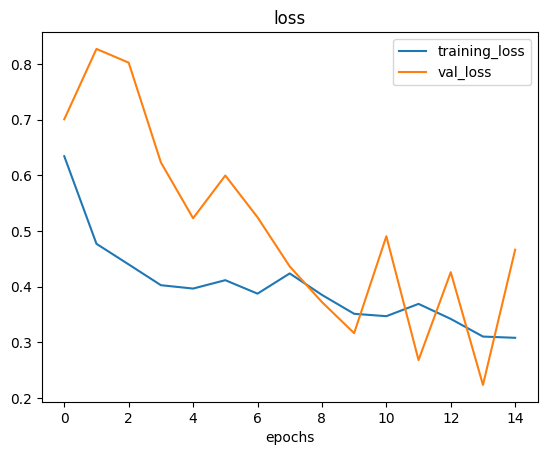

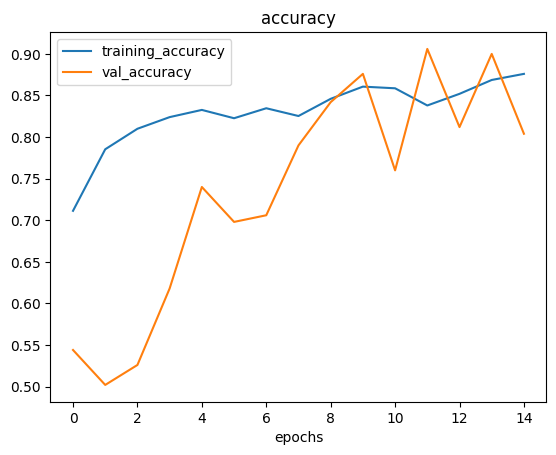

In [ ]:
# Plot the loss curves
plot_loss_curves(history_4)

### Making predictions with our pretrained model on custom data

In [ ]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
steak = mp.imread("03-steak.jpeg")

--2026-04-09 09:29:13--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘03-steak.jpeg’

03-steak.jpeg       100%[===================>]   1.89M  --.-KB/s    in 0.03s   

2026-04-09 09:29:13 (59.4 MB/s) - ‘03-steak.jpeg’ saved [1978213/1978213]



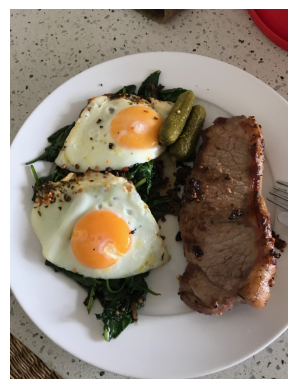

In [ ]:
plt.imshow(steak)
plt.axis(False);

In [ ]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=(224)):
  """Reads an image from filename, turns it into a tensor and reshapes it to (img_shape, img_shape, color_channel)"""
  # Read in the image
  img = tf.io.read_file(filename)
  # Decode the read file into a tensor
  img = tf.image.decode_image(img)
  # resize the image
  img = tf.image.resize(img, size=[img_shape, img_shape])
  # Rescale the image and get values between 0 and 1
  img = img/255.
  return img

In [ ]:
# Load in and preprocess our image
steak = load_and_prep_image("03-steak.jpeg")
steak

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.6377451 , 0.6220588 , 0.57892156],
        [0.6504902 , 0.63186276, 0.5897059 ],
        [0.63186276, 0.60833335, 0.5612745 ],
        ...,
        [0.52156866, 0.05098039, 0.09019608],
        [0.49509802, 0.04215686, 0.07058824],
        [0.52843136, 0.07745098, 0.10490196]],

       [[0.6617647 , 0.6460784 , 0.6107843 ],
        [0.6387255 , 0.6230392 , 0.57598037],
        [0.65588236, 0.63235295, 0.5852941 ],
        ...,
        [0.5352941 , 0.06862745, 0.09215686],
        [0.529902  , 0.05931373, 0.09460784],
        [0.5142157 , 0.05539216, 0.08676471]],

       [[0.6519608 , 0.6362745 , 0.5892157 ],
        [0.6392157 , 0.6137255 , 0.56764704],
        [0.65637255, 0.6269608 , 0.5828431 ],
        ...,
        [0.53137255, 0.06470589, 0.08039216],
        [0.527451  , 0.06862745, 0.1       ],
        [0.52254903, 0.05196078, 0.0872549 ]],

       ...,

       [[0.49313724, 0.42745098, 0.31029412],
        [0.05

In [ ]:
pred = model_4.predict(tf.expand_dims(steak, axis=0))
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


array([[0.8614622]], dtype=float32)

In [ ]:
class_names

array(['pizza', 'steak'], dtype='<U5')

In [ ]:
# Index the predicted class
pred_class = class_names[int(tf.round(pred)[0][0])]
pred_class

np.str_('steak')

In [ ]:
def pred_and_plot(model, filename, class_names=class_names):
  """Import an image located at filename, amkes a prediction with model and plots the image with the predicted class as the title"""
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)
  # Make a predictions
  pred = model.predict(tf.expand_dims(img, axis=0))
  # Get the predicted class
  pred_class = class_names[int(tf.round(pred))]
  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step


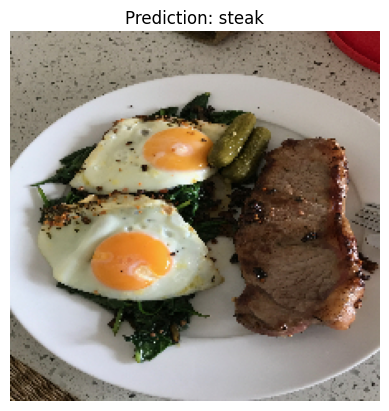

In [ ]:
# Test our model on a custom image
pred_and_plot(model_4, "03-steak.jpeg")

--2026-04-09 10:39:33--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2874848 (2.7M) [image/jpeg]
Saving to: ‘03-pizza-dad.jpeg.1’

03-pizza-dad.jpeg.1 100%[===================>]   2.74M  --.-KB/s    in 0.05s   

2026-04-09 10:39:34 (60.3 MB/s) - ‘03-pizza-dad.jpeg.1’ saved [2874848/2874848]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


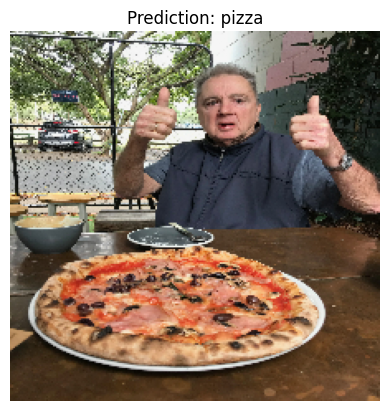

In [ ]:
# Download another test custom image
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
pred_and_plot(model_4, "03-pizza-dad.jpeg")